Initialize a Series System and Simulate Operation

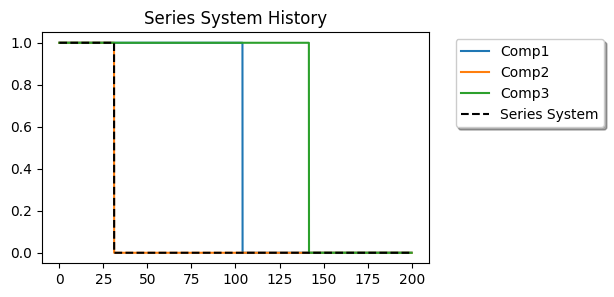

In [1]:
from system_objects.series_system import SeriesSystem
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt

# create 3 exponential components
comps = [ExponentialComponent(name=f"Comp{i+1}", MTTF= 100, MTTR= 10) for i in range(3)]

# create a series system with these components
system = SeriesSystem(name="Series System", components=comps)

# simulate operation for 200 time units
system.simulate(t_end = 200, dt= 0.01)

# plot the system history along with component histories
plt.figure(figsize=(5, 3))
system.plot_history(plot_comps=True)
plt.show()

Initialize a Parallel System and Simulate Operation

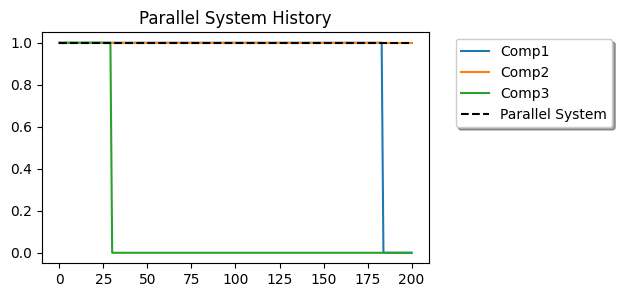

In [2]:
from system_objects.parallel_system import ParallelSystem
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt

# create 3 exponential components
comps = [ExponentialComponent(name=f"Comp{i+1}", MTTF= 100, MTTR= 10) for i in range(3)]

# create a parallel system with these components
system = ParallelSystem(name="Parallel System", components=comps)

# simulate operation for 200 time units
system.simulate(t_end = 200, dt= 1)

# plot the system history along with component histories
plt.figure(figsize=(5, 3))
system.plot_history(plot_comps=True)

Initialize a k-out-of-N system

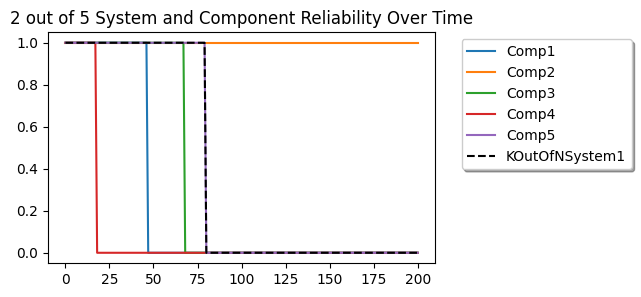

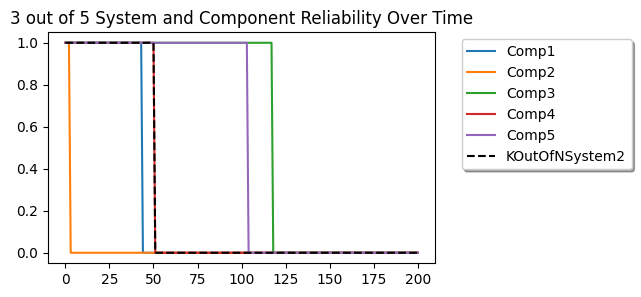

In [3]:
from system_objects.kooN_system import KOutOfNSystem
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt

# create 3 exponential components
comps = [ExponentialComponent(name=f"Comp{i+1}", MTTF= 100, MTTR= 10) for i in range(5)]
comps2 = [ExponentialComponent(name=f"Comp{i+1}", MTTF= 100, MTTR= 10) for i in range(5)]

# create a k-out-of-n system with these components
system = KOutOfNSystem(name="KOutOfNSystem1", components=comps, k=2)    # 2 out of 5
system2 = KOutOfNSystem(name="KOutOfNSystem2", components=comps2, k=3)    # 3 out of 5

# simulate operation for 200 time units
system.simulate(t_end = 200, dt= 1)
system2.simulate(t_end = 200, dt= 1)

# plot the system history along with component histories
plt.figure(figsize=(5, 3))
system.plot_history(plot_comps=True)
plt.title("2 out of 5 System and Component Reliability Over Time")
plt.show()

plt.figure(figsize=(5, 3))
system2.plot_history(plot_comps=True)
plt.title("3 out of 5 System and Component Reliability Over Time")
plt.show()

Testing More Complex System of Systems

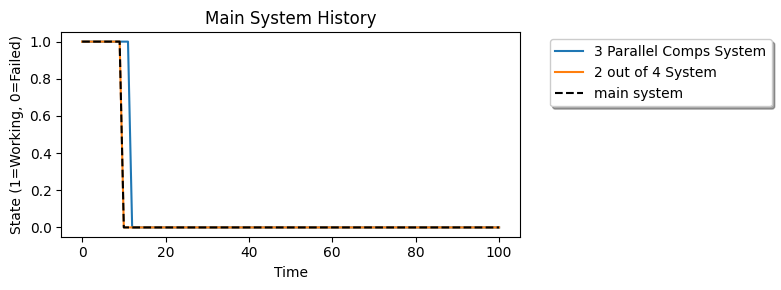

In [5]:
from system_objects.series_system import SeriesSystem
from system_objects.parallel_system import ParallelSystem
from system_objects.kooN_system import KOutOfNSystem
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt

comps = [ExponentialComponent(name = f"Comp {i+1}", MTTF=10, MTTR=10) for i in range(7)]

sub_sys1 = ParallelSystem(name ="3 Parallel Comps System", components=comps[:3])
sub_sys2 = KOutOfNSystem(name ="2 out of 4 System", components = comps[3:], k=2)

sys = SeriesSystem(name="main system", components=[sub_sys1, sub_sys2])
sys.simulate(100, 1)

# plot all histories on seperate figures
plt.figure(figsize=(8, 3))
sys.plot_history(plot_comps=True)
# plt.figure(figsize=(5, 3))
# sub_sys1.plot_history(plot_comps=True)
# plt.figure(figsize=(5, 3))
# sub_sys2.plot_history(plot_comps=True)